In [70]:
# temporary imports (should be included in next image iteration)
!pip install matplotlib
!pip install pandas

In [32]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

In [33]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [34]:
FREESOUND_API_KEY = ""
with open("../fsk.env", "r") as f:
    FREESOUND_API_KEY = f.read().split("=")[1]
    FREESOUND_API_KEY = FREESOUND_API_KEY.replace("\n", "").replace('"','')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [40]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets
)

In [35]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [46]:
# Queries for THIS RUN
freesound_queries = [
    {
        "query": "water droplets",
        "filter": None,
        "num_results": 20,
    },
]

In [47]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = []
for q in freesound_queries:
    sounds.extend(
        query_freesound(
            query=q["query"],
            filter=q["filter"],
            client=client,
            fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
            num_results=q["num_results"],
        )
    )

print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, AUDIO_DIR)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, AUDIO_DIR)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "queries": freesound_queries,
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 20 sound metadata objects
[1/20] Downloading sound ID 392116
[2/20] Downloading sound ID 533146
[3/20] Downloading sound ID 238919
[4/20] Downloading sound ID 343168
[5/20] Downloading sound ID 424845
[6/20] Downloading sound ID 485041
[7/20] Downloading sound ID 772883
[8/20] Downloading sound ID 260842
[9/20] Downloading sound ID 337575
[10/20] Downloading sound ID 722412
[11/20] Downloading sound ID 755100
[12/20] Downloading sound ID 823211
[13/20] Downloading sound ID 267221
[14/20] Downloading sound ID 612133
[15/20] Downloading sound ID 823210
[16/20] Downloading sound ID 514404
[17/20] Downloading sound ID 353692
[18/20] Downloading sound ID 510408
[19/20] Downloading sound ID 540002
[20/20] Downloading sound ID 244231
Saved metadata CSV: ../data/meta/dataset_2026-01-18_18-29-36.csv
Saved query log JSON: ../data/meta/dataset_2026-01-18_18-29-36.json


In [71]:
!ls ../data/meta

dataset_2026-01-12_16-08-56.csv   dataset_2026-01-18_13-58-47.json
dataset_2026-01-12_16-08-56.json  dataset_2026-01-18_18-29-36.csv
dataset_2026-01-18_13-58-47.csv   dataset_2026-01-18_18-29-36.json


In [78]:
delete_dataset_with_gc(META_DIR + "dataset_2026-01-18_18-29-36.csv", META_DIR, AUDIO_DIR, dry_run=False)

Deleted metadata file: /workspace/data/meta/dataset_2026-01-18_18-29-36.csv
Deleted query file: /workspace/data/meta/dataset_2026-01-18_18-29-36.json
Deleted audio: /workspace/data/audio/540002_11959822-hq.ogg
Deleted audio: /workspace/data/audio/343168_6071037-hq.ogg
Deleted audio: /workspace/data/audio/514404_1738686-hq.ogg
Deleted audio: /workspace/data/audio/392116_245603-hq.ogg
Deleted audio: /workspace/data/audio/337575_1490240-hq.ogg
Deleted audio: /workspace/data/audio/353692_1431924-hq.ogg
Deleted audio: /workspace/data/audio/772883_6753194-hq.ogg
Deleted audio: /workspace/data/audio/485041_9453283-hq.ogg
Deleted audio: /workspace/data/audio/722412_1490240-hq.ogg
Deleted audio: /workspace/data/audio/244231_4463962-hq.ogg
Deleted audio: /workspace/data/audio/823211_17278148-hq.ogg
Deleted audio: /workspace/data/audio/238919_3406193-hq.ogg
Deleted audio: /workspace/data/audio/267221_3112522-hq.ogg
Deleted audio: /workspace/data/audio/424845_8508138-hq.ogg
Deleted audio: /workspa

### Show downloaded audio

In [57]:
!ls -lt ../data/audio

total 5944
-rw-r--r-- 1 root root  55461 Jan 18 18:29 244231_4463962-hq.ogg
-rw-r--r-- 1 root root  84946 Jan 18 18:29 540002_11959822-hq.ogg
-rw-r--r-- 1 root root  11813 Jan 18 18:29 510408_5728746-hq.ogg
-rw-r--r-- 1 root root   6391 Jan 18 18:29 353692_1431924-hq.ogg
-rw-r--r-- 1 root root 115813 Jan 18 18:29 514404_1738686-hq.ogg
-rw-r--r-- 1 root root  79239 Jan 18 18:29 823210_17278148-hq.ogg
-rw-r--r-- 1 root root  42242 Jan 18 18:29 612133_6512859-hq.ogg
-rw-r--r-- 1 root root  12096 Jan 18 18:29 267221_3112522-hq.ogg
-rw-r--r-- 1 root root  78502 Jan 18 18:29 823211_17278148-hq.ogg
-rw-r--r-- 1 root root  14421 Jan 18 18:29 755100_16303716-hq.ogg
-rw-r--r-- 1 root root 120892 Jan 18 18:29 722412_1490240-hq.ogg
-rw-r--r-- 1 root root 170526 Jan 18 18:29 337575_1490240-hq.ogg
-rw-r--r-- 1 root root 355256 Jan 18 18:29 260842_3452716-hq.ogg
-rw-r--r-- 1 root root 114612 Jan 18 18:29 772883_6753194-hq.ogg
-rw-r--r-- 1 root root  24786 Jan 18 18:29 485041_9453283-hq.ogg
-rw-r--r--

In [69]:
# select a file manually
filename = "510408_5728746-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/510408_5728746-hq.ogg'

In [61]:
# select a file randomly
filename = random.choice(os.listdir(AUDIO_DIR))
filename = AUDIO_DIR + filename
filename

'../data/audio/160093_2888453-hq.ogg'

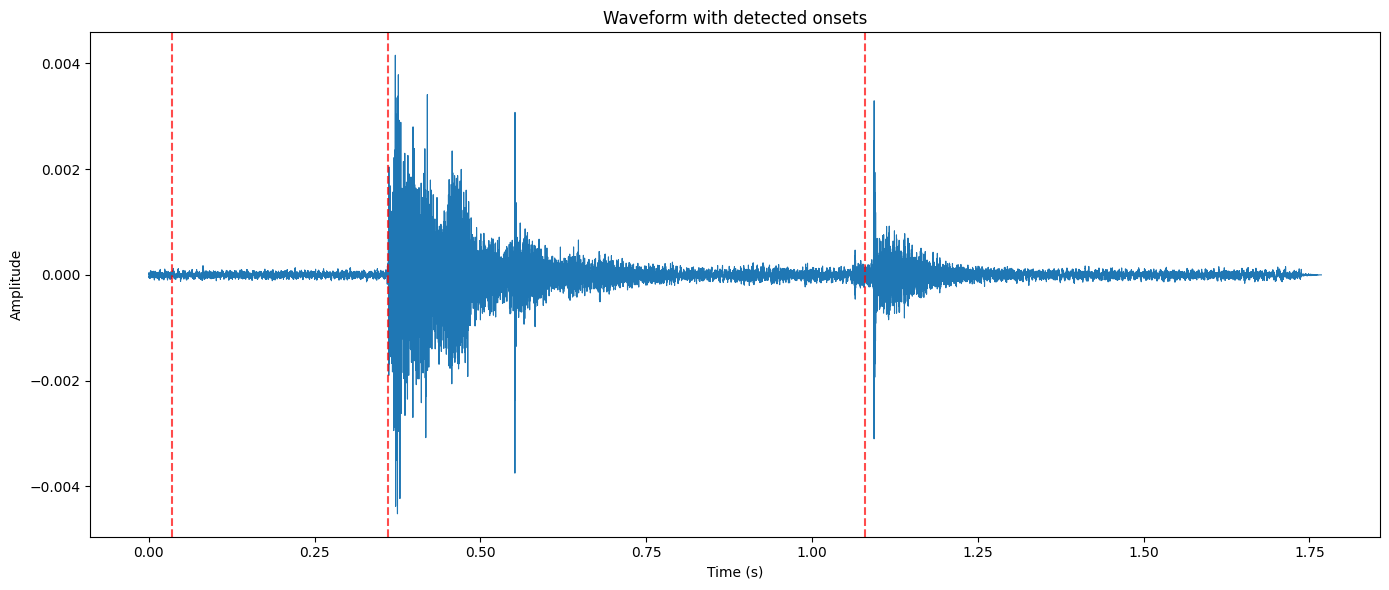

In [70]:
start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filename)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)